In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [5]:
class BmiState(TypedDict):
    weight_in_kg: float
    height_in_m: float
    bmi: float
    category: str

In [6]:
def calculateBMI(state: BmiState) -> BmiState:
    weight = state['weight_in_kg']
    height = state['height_in_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

In [10]:
def categorize(state: BmiState) -> BmiState:
    bmi = state['bmi']

    if bmi<18:
        state['category'] = 'Underweight'
    elif bmi<25:
        state['category'] = 'Healthy'
    elif bmi<30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'

    return state

In [11]:
# GRAPH CONSTRUCTION
graph = StateGraph(BmiState)

# ADDING NODE
graph.add_node('calculateBMI', calculateBMI)
graph.add_node('categorize', categorize)

# ADDING EDGES
graph.add_edge(START, 'calculateBMI')
graph.add_edge('calculateBMI', 'categorize')
graph.add_edge('categorize', END)

# GRAPH COMPILATION
workflow = graph.compile()

In [12]:
input_state = {"weight_in_kg": 65, "height_in_m": 1.7}
output_state = workflow.invoke(input_state)

print(output_state)

{'weight_in_kg': 65, 'height_in_m': 1.7, 'bmi': 22.49, 'category': 'Healthy'}


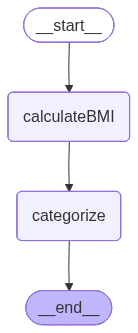

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())